In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def f(t, y):
    return y**2 - 10

def fprime(t, y):
    return 2*y


# Newton-Raphson for single step with Backward Euler
def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=50):
    y_next = y  # Initial guess
    
    for _ in range(max_iter):
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(t, y_next)    
        
        if abs(g_prime_val) < tol:  # Avoid division by zero
            break
            
        y_new = y_next - g_val / g_prime_val
        if abs(y_new - y_next) < tol:
            return y_new  # Converged
        
        y_next = y_new
    return y_next


# Adaptive Backward Euler
def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=50):
    t_values = [t0]
    y_values = [y0]
    h = h_init
    t = t0
    y = y0
    
    while t < tf:
        if t + h > tf:  # Adjust step size to not overshoot
            h = tf - t
            
        # Single step with h
        y_full = backward_euler_step(f, y, t, h, tol, max_iter)
        
        # Two half-steps with h/2
        h_half = h / 2
        y_half_1 = backward_euler_step(f, y, t, h_half, tol, max_iter)
        y_half_2 = backward_euler_step(f, y_half_1, t + h_half, h_half, tol, max_iter)
        
        # Error estimation
        error = abs(y_full - y_half_2)
        
        # Adjust step size
        if error > tol:
            h /= 2  # Decrease step size
            continue  # Retry the step with smaller h
            
        elif error < tol / 2:
            h *= 2  # Increase step size for efficiency
            
        # Accept the step
        t += h
        y = y_half_2
        t_values.append(t)
        y_values.append(y)

    return np.array(t_values), np.array(y_values)

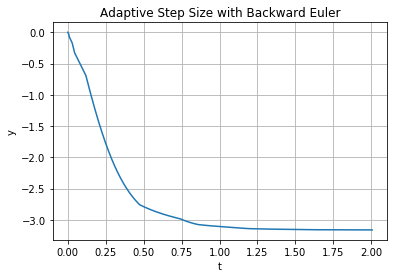

In [7]:
y0 = 0
t0 = 0
tf = 2
h_init = 0.1

t_values, y_values = backward_euler_adaptive(f, y0, t0, tf, h_init)
plt.plot(t_values, y_values)
plt.xlabel('t')
plt.ylabel('y')
plt.grid()
plt.title('Adaptive Step Size with Backward Euler')
plt.show()

The Adaptive Step Size with Backward Euler is both computationally efficient and high stability. Changing the step size allows you to adjust what step size you need without compromising efficiency in different parts of the graph. The waves that can be 